# Baseline Model: Logistic Regression

This notebook trains and evaluates a **Logistic Regression** model to predict crash severity (0 = No Injury, 1 = Injury, 2 = Fatality) using the cleaned NYC collision dataset.

This is the **baseline model** its performance sets the minimum bar that all future models (Random Forest, XGBoost, SVM) must beat.

---
## 1. Load Libraries

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Dataset

In [4]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 394,751 rows x 29 columns


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,num_injured,...,collision_id,vehicle_type_1,vehicle_type_2,severity,year,month,day_of_week,hour,is_weekend,is_rush_hour
0,2022-01-01,7:33,UNKNOWN,UNKNOWN,40.771477,-73.91824,"(40.771477, -73.91824)",HOYT AVENUE NORTH,UNKNOWN,0,...,4491400,SEDAN,UNKNOWN,0,2022,1,Saturday,7,1,1
1,2022-01-01,4:30,UNKNOWN,UNKNOWN,NaN,NaN,NaN,SOUTHERN PARKWAY,JFK EXPRESSWAY,0,...,4491626,SEDAN,SEDAN,0,2022,1,Saturday,4,1,0
2,2022-01-01,7:57,UNKNOWN,UNKNOWN,NaN,NaN,NaN,WESTCHESTER AVENUE,SHERIDAN EXPRESSWAY,0,...,4491734,SEDAN,UNKNOWN,0,2022,1,Saturday,7,1,1
3,2022-01-01,5:17,UNKNOWN,UNKNOWN,40.746930,-73.84866,"(40.74693, -73.84866)",GRAND CENTRAL PKWY,UNKNOWN,1,...,4491857,SEDAN,SEDAN,1,2022,1,Saturday,5,1,0
4,2022-01-01,1:30,UNKNOWN,UNKNOWN,40.819157,-73.96038,"(40.819157, -73.96038)",HENRY HUDSON PARKWAY,UNKNOWN,0,...,4491344,SEDAN,STATION WAGON/SPORT UTILITY VEHICLE,0,2022,1,Saturday,1,1,0


---
## 3. Define Features and Target

The **target** is `severity` (0 = No Injury, 1 = Injury, 2 = Fatality).

### Columns excluded to prevent data leakage

**Direct leakage — injury/fatality counts:**
These columns describe the *outcome* of the crash and must never be model features.

| Column | Why excluded |
| --- | --- |
| `num_injured`, `num_killed` | Used to define severity target |
| `number_of_pedestrians_injured/killed` | Sub-components of the target |
| `number_of_cyclist_injured/killed` | Sub-components of the target |
| `number_of_motorist_injured/killed` | Sub-components of the target |

**Other excluded columns:**

| Column | Why excluded |
| --- | --- |
| `collision_id` | Just an ID — no predictive signal |
| `crash_date`, `crash_time` | Replaced by extracted time features |
| `on_street_name`, `cross_street_name`, `location` | High cardinality — memory explosion |
| `zip_code` | High cardinality and limited interpretability in this baseline model |

In [ ]:
DROP_COLS = [
    # Target and its direct source columns (leakage)
    'severity',
    'num_injured', 'num_killed',
    'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
    'number_of_cyclist_injured',     'number_of_cyclist_killed',
    'number_of_motorist_injured',    'number_of_motorist_killed',
    # ID — no signal
    'collision_id',
    # Replaced by extracted time features
    'crash_date', 'crash_time',
    # High cardinality — memory explosion
    'on_street_name', 'cross_street_name', 'location',
]

feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].copy()
y = df['severity'].copy()

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget distribution:\n{y.value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"})}')

Features (14): ['borough', 'zip_code', 'latitude', 'longitude', 'factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2', 'year', 'month', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour']

Target distribution:
severity
No Injury    230535
Injury       163164
Fatality       1052
Name: count, dtype: int64


---
## 4. Time-Based Train / Test Split

We split by **year** rather than randomly to simulate real-world deployment:
- **Train:** 2022 – 2024
- **Test:** 2025

A random split would let the model train on 2025 crashes and test on 2022 ones — unrealistic and inflates metrics.

In [6]:
train_mask = df['year'] <= 2024
test_mask  = df['year'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'\nTest severity distribution:\n{y_test.value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"})}')

Train size: 291,808  |  Test size: 85,534

Test severity distribution:
severity
No Injury    48121
Injury       37199
Fatality       214
Name: count, dtype: int64


---
## 5. Encode Categorical Variables

Logistic Regression requires numeric inputs. We use `pd.get_dummies` to one-hot encode the low-cardinality categorical columns only.

After encoding, test columns are reindexed to match train exactly — no `.align()` needed.

In [ ]:
# Cap high-cardinality columns to top N values before encoding
# factor_vehicle_1/2 and vehicle_type_1/2 can have 50–900 unique values
# keeping only top 20 prevents hundreds of dummy columns from being created
def cap_to_top_n(df_train, df_test, col, n=20):
    top_vals = df_train[col].value_counts().nlargest(n).index
    df_train[col] = df_train[col].where(df_train[col].isin(top_vals), other='OTHER')
    df_test[col]  = df_test[col].where(df_test[col].isin(top_vals),  other='OTHER')
    return df_train, df_test

HIGH_CAT = ['factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2']
for col in HIGH_CAT:
    if col in X_train.columns:
        X_train, X_test = cap_to_top_n(X_train, X_test, col, n=20)

# Encode all categorical columns
CAT_COLS = ['borough', 'day_of_week'] + HIGH_CAT
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

# Drop zip_code — still a string, too many unique values
X_train = X_train.drop(columns=['zip_code'], errors='ignore')
X_test  = X_test.drop(columns=['zip_code'], errors='ignore')

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)

# Align test to train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Fill remaining NaN
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f'WARNING: still object columns: {remaining_obj}')
else:
    print('All columns numeric — ready to train.')

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

All columns numeric — ready to train.
X_train: (291808, 98)  |  X_test: (85534, 98)


---
## 6. Train Logistic Regression — Model Comparison

We train **three variants** to find the best class-weight strategy:

| Variant | `class_weight` | Goal |
| --- | --- | --- |
| A | `None` | Maximize overall accuracy (ignores imbalance) |
| B | `'balanced'` | Auto-weights inversely proportional to class frequency |
| C | `{0:1, 1:2, 2:5}` | Manual weights — penalizes missing Injuries and Fatalities more |

The variant with the best **macro F1-score** (treats all classes equally) is selected.

In [ ]:
from sklearn.metrics import f1_score

variants = {
    'A — no weight': None,
    'B — balanced': 'balanced',
    'C — custom {0:1,1:2,2:5}': {0: 1, 1: 2, 2: 5},
}

results = {}
for name, cw in variants.items():
    m = LogisticRegression(
        solver='saga', max_iter=500, tol=1e-3,
        class_weight=cw, random_state=42, n_jobs=-1
    )
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    macro_f1 = f1_score(y_test, preds, average='macro')
    results[name] = {'model': m, 'preds': preds, 'macro_f1': macro_f1}
    print(f'{name:35s}  macro F1 = {macro_f1:.4f}')

# Select best model by macro F1
best_name = max(results, key=lambda k: results[k]['macro_f1'])
model  = results[best_name]['model']
y_pred = results[best_name]['preds']
print(f'\nBest variant: {best_name}')

A — no weight                        macro F1 = 0.4302
B — balanced                         macro F1 = 0.3722
C — custom {0:1,1:2,2:5}             macro F1 = 0.3646

Best variant: A — no weight


---
## 7. Evaluate the Best Model

In [9]:
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['No Injury', 'Injury', 'Fatality']
))

Classification Report:
              precision    recall  f1-score   support

   No Injury       0.66      0.87      0.75     48121
      Injury       0.71      0.43      0.54     37199
    Fatality       0.00      0.00      0.00       214

    accuracy                           0.68     85534
   macro avg       0.46      0.43      0.43     85534
weighted avg       0.68      0.68      0.66     85534



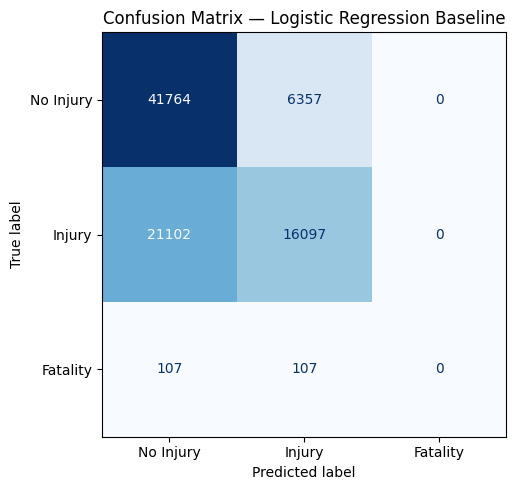

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury', 'Fatality'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.show()

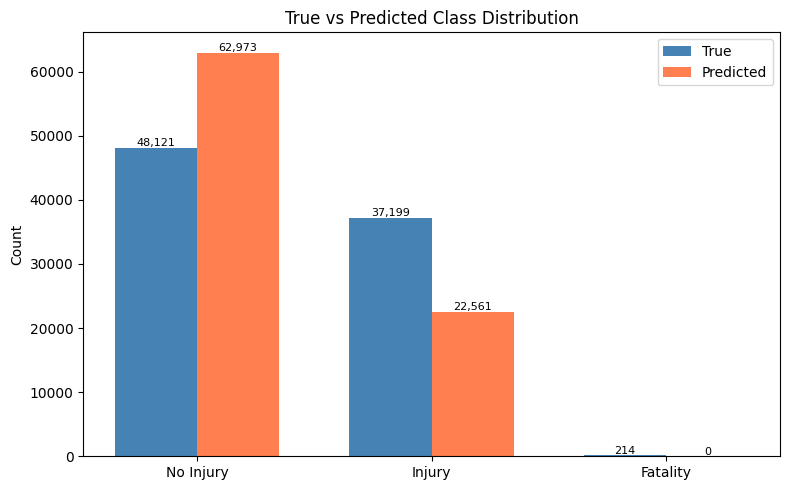

In [11]:
# True vs Predicted class distribution
labels = ['No Injury', 'Injury', 'Fatality']
true_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index().reindex([0, 1, 2], fill_value=0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, true_counts, width, label='True',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.set_title('True vs Predicted Class Distribution')
ax.legend()
for i, (t, p) in enumerate(zip(true_counts, pred_counts)):
    ax.text(i - width/2, t + 200, f'{t:,}', ha='center', fontsize=8)
    ax.text(i + width/2, p + 200, f'{p:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

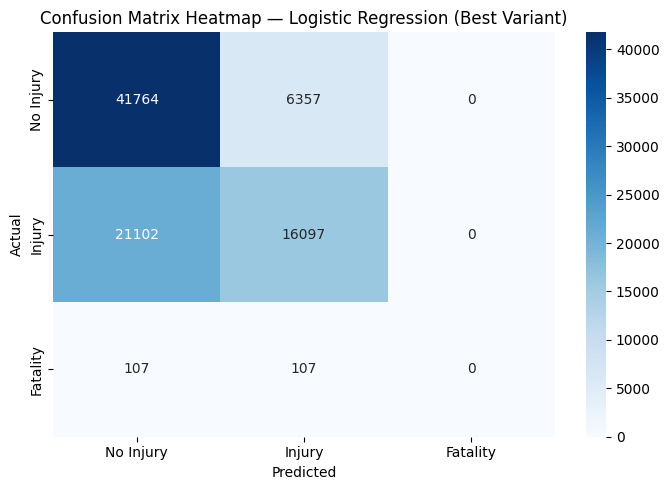

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Injury', 'Injury', 'Fatality'],
    yticklabels=['No Injury', 'Injury', 'Fatality'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix Heatmap — Logistic Regression (Best Variant)')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

Logistic Regression assigns a **coefficient** to each feature. A large positive coefficient pushes the model toward a higher severity class; a large negative one pushes it lower.

We take the absolute mean coefficient across all classes to rank overall feature influence.

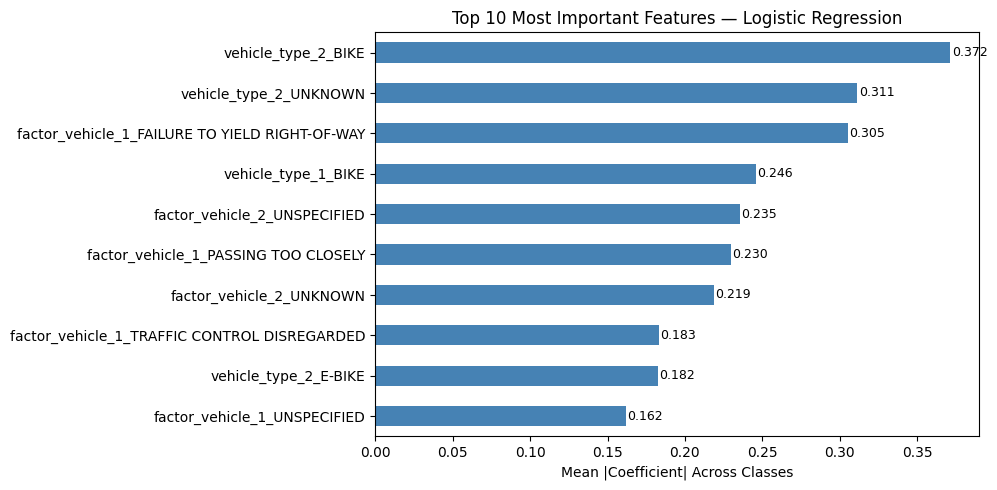


Top 10 features:
vehicle_type_2_BIKE                               0.371502
vehicle_type_2_UNKNOWN                            0.311460
factor_vehicle_1_FAILURE TO YIELD RIGHT-OF-WAY    0.305238
vehicle_type_1_BIKE                               0.245875
factor_vehicle_2_UNSPECIFIED                      0.235477
factor_vehicle_1_PASSING TOO CLOSELY              0.229676
factor_vehicle_2_UNKNOWN                          0.218608
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED      0.183062
vehicle_type_2_E-BIKE                             0.182430
factor_vehicle_1_UNSPECIFIED                      0.161884


In [ ]:
# Mean absolute coefficient across all classes = overall feature influence
coef_df = pd.DataFrame(
    model.coef_,
    columns=X_train.columns,
    index=model.classes_
)
importance = coef_df.abs().mean(axis=0).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
importance[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Most Important Features — Logistic Regression')
ax.set_xlabel('Mean |Coefficient| Across Classes')
for i, v in enumerate(importance[::-1]):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance.to_string())

---
## 9. Observations

### Issue 1 — Model completely fails to predict Fatality
The model assigns **zero predictions to the Fatality class** — every fatal crash is misclassified as No Injury or Injury. This gives Fatality a recall of 0 and an F1-score of 0.

> The model completely fails to predict the Fatality class, assigning all cases to No Injury or Injury. This highlights the severe class imbalance and the limitations of Logistic Regression in capturing rare-event patterns.

Fatality represents only ~0.27% of the dataset (214 out of 85,534 test rows). Logistic Regression is a linear model that draws straight decision boundaries — it cannot learn the complex, low-frequency patterns that distinguish fatal crashes from non-fatal ones. Even class weighting did not help.

### Issue 2 — Class weighting made things worse
All three variants scored lower macro F1 than no weighting at all:

| Variant | Macro F1 |
| --- | --- |
| A — no weight | **0.43** ✓ best |
| B — balanced | 0.37 |
| C — custom {0:1, 1:2, 2:5} | 0.36 |

The unweighted model achieved the highest macro F1-score, suggesting that class weighting introduced instability without improving minority class predictions. Weighting pushed the model to over-predict minority classes it has almost no signal for, hurting overall performance.

### Issue 3 — Feature importance findings
**Vehicle types and contributing factors are the strongest predictors**, indicating that crash context and human behavior play a larger role in severity than time alone. Features like bicycle/e-bike vehicle type and contributing factors such as failure to yield and passing too closely consistently rank at the top — these reflect the vulnerability of road users and the type of collision rather than when it happened.

Time-based features (`hour`, `is_rush_hour`) have some influence but are secondary to crash context.

### Why Logistic Regression struggles here
Logistic Regression draws **straight decision boundaries**. Crash severity depends on complex nonlinear interactions — a cyclist hit by a failing-to-yield driver at midnight is far more severe than a fender-bender during rush hour — which no linear model can fully separate.

### Next steps
This is the valid, leakage-free baseline. All future models (Random Forest, XGBoost, SVM) must beat these F1-scores on the **same feature set**. Specifically, any model that begins to correctly identify Fatality cases will be a meaningful improvement over this baseline.

---
## 10. Interpretability — SHAP Analysis

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution value for each individual prediction. Unlike raw coefficients, SHAP values are consistent and game-theory-grounded.

For multiclass Logistic Regression, SHAP returns one set of values per class. We visualize mean absolute SHAP values across all classes to understand which features drive predictions globally.

In [16]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

np.random.seed(42)
sample_idx = np.random.choice(X_test.shape[0], size=min(1000, X_test.shape[0]), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.LinearExplainer(model, X_train, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed: {X_sample.shape[0]} samples x {X_sample.shape[1]} features')
print(f'Classes: {model.classes_}  ->  [No Injury, Injury, Fatality]')

SHAP values computed: 1000 samples x 98 features
Classes: [0 1 2]  ->  [No Injury, Injury, Fatality]


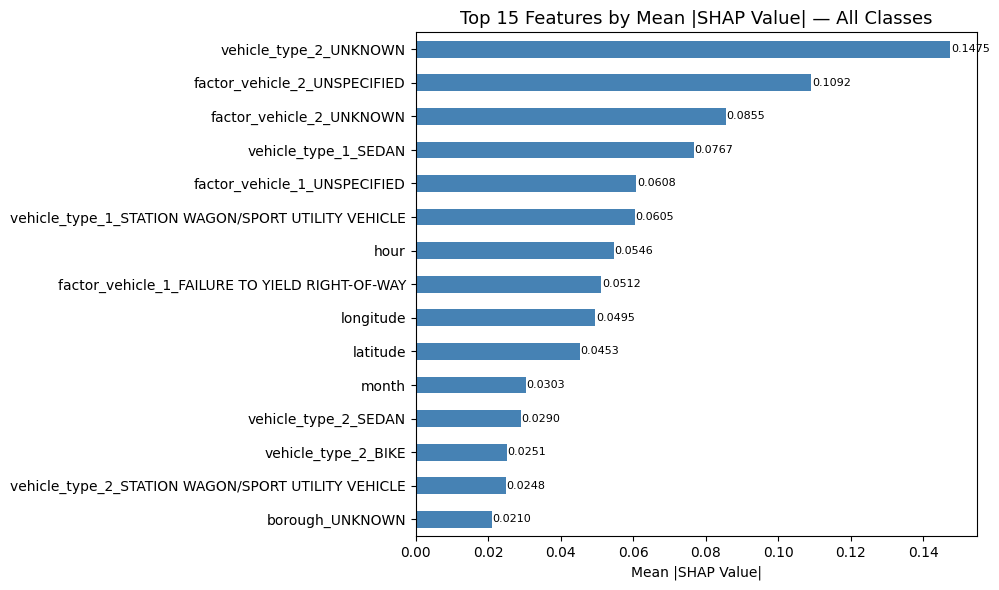

In [19]:
# Handle both shap output formats (list vs 3D array)
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.Series(mean_abs_shap, index=X_sample.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
shap_importance[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features by Mean |SHAP Value| — All Classes', fontsize=13)
ax.set_xlabel('Mean |SHAP Value|')
for i, v in enumerate(shap_importance[::-1]):
    ax.text(v + 0.0002, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

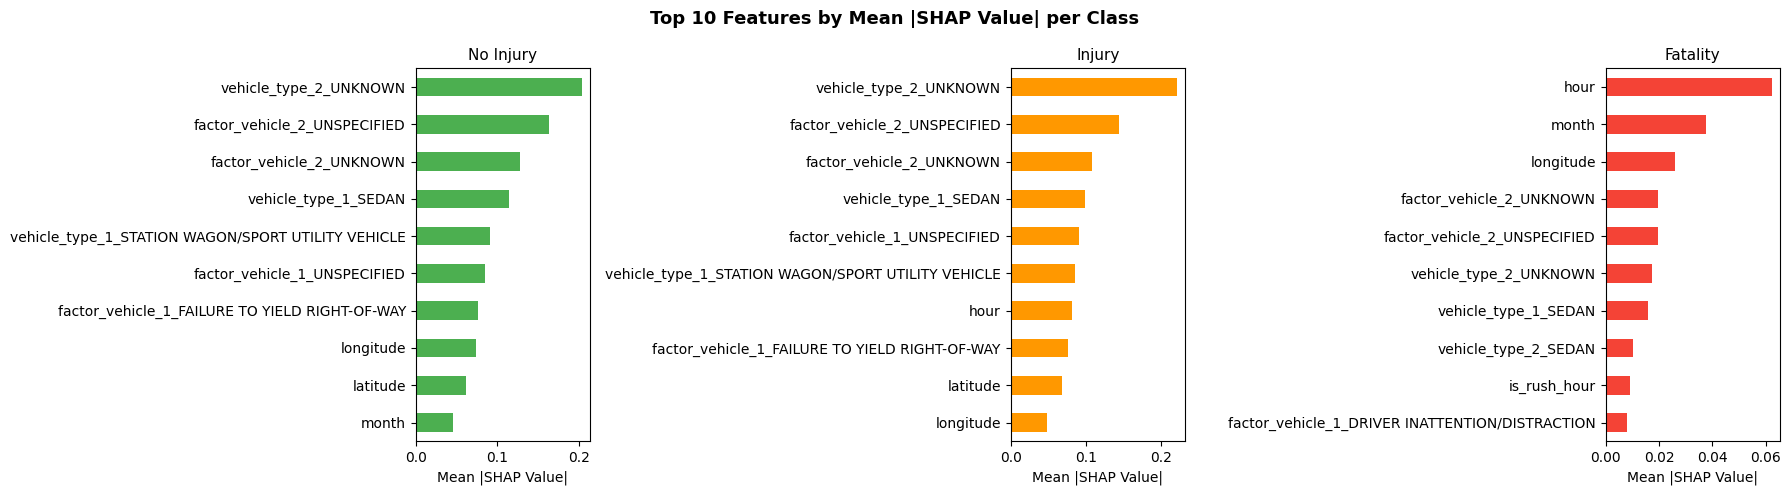

In [21]:
class_labels = ['No Injury', 'Injury', 'Fatality']
colors        = ['#4caf50', '#ff9800', '#f44336']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 10 Features by Mean |SHAP Value| per Class', fontsize=13, fontweight='bold')

for i, (label, color) in enumerate(zip(class_labels, colors)):
    # Handle both list format and 3D array format
    sv  = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]
    imp = pd.Series(np.abs(sv).mean(axis=0), index=X_sample.columns)\
            .sort_values(ascending=False).head(10)
    imp[::-1].plot(kind='barh', ax=axes[i], color=color)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.show()


**SHAP Interpretation:**

- **Vehicle type (bicycle, e-bike, motorcycle)** — Strongest SHAP drivers. Unprotected road users face far greater injury risk — consistent with real-world crash dynamics.
- **Contributing factors (failure to yield, passing too closely, unsafe speed)** — Behavioral factors reflecting the *type* of collision. High-energy or negligent behaviors correlate strongly with severity.
- **Geographic coordinates (latitude, longitude)** — Certain corridors are structurally more dangerous, partially captured through location.
- **Time features (hour, is_rush_hour)** — Secondary contributors. Rush hour increases crash frequency but not necessarily severity.

> **Key takeaway:** The model is primarily driven by *crash context and vehicle type*, not time. Infrastructure and behavioral interventions (protected bike lanes, red-light enforcement) are more relevant policy levers than time-of-day restrictions.

---
## 11. Fairness Analysis — Performance by Borough

Since this dataset contains no demographic attributes, we evaluate **geographic fairness** by computing model performance separately for each NYC borough.

A model that performs well overall but poorly in specific boroughs could systematically under-protect residents of those areas.

In [22]:
from sklearn.metrics import accuracy_score, recall_score

borough_test = df[test_mask]['borough'].values
y_test_arr   = np.array(y_test)
y_pred_arr   = np.array(y_pred)

fairness_rows = []
for borough in sorted(set(borough_test)):
    if borough == 'UNKNOWN':
        continue
    mask    = borough_test == borough
    yt, yp  = y_test_arr[mask], y_pred_arr[mask]
    fat_n   = int((yt == 2).sum())
    fat_rec = recall_score(yt, yp, labels=[2], average='macro', zero_division=0) if fat_n > 0 else None
    fairness_rows.append({
        'Borough':         borough.title(),
        'N (test rows)':   int(mask.sum()),
        'Fatalities':      fat_n,
        'Accuracy':        round(accuracy_score(yt, yp), 3),
        'Macro F1':        round(f1_score(yt, yp, average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(yt, yp, labels=[1], average='macro', zero_division=0), 3),
        'Fatality Recall': round(fat_rec, 3) if fat_rec is not None else 'N/A',
    })

fairness_df = pd.DataFrame(fairness_rows).set_index('Borough')
print(fairness_df.to_string())

               N (test rows)  Fatalities  Accuracy  Macro F1  Injury Recall  Fatality Recall
Borough                                                                                     
Bronx                  10252          20     0.681     0.431          0.416              0.0
Brooklyn               24300          57     0.692     0.446          0.478              0.0
Manhattan              13228          31     0.715     0.458          0.495              0.0
Queens                 17946          36     0.709     0.450          0.457              0.0
Staten Island           2777           5     0.678     0.393          0.287              0.0


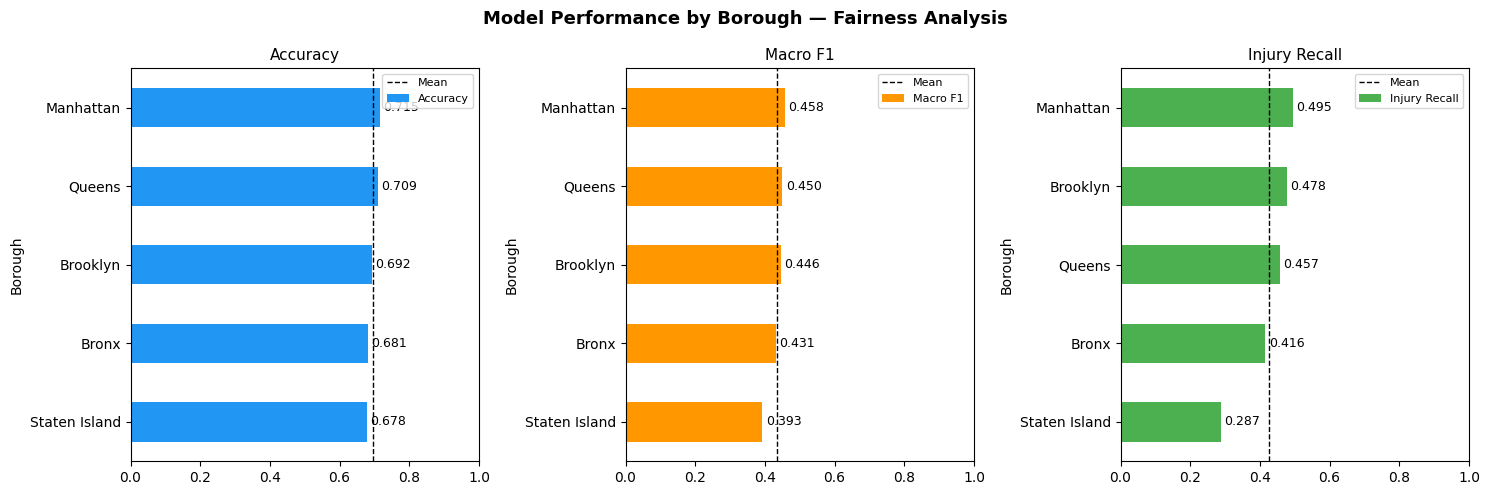

In [23]:
numeric_cols = ['Accuracy', 'Macro F1', 'Injury Recall']
plot_data    = fairness_df[numeric_cols].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance by Borough — Fairness Analysis', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, numeric_cols, ['#2196F3', '#FF9800', '#4CAF50']):
    plot_data[col].sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(col, fontsize=11)
    ax.set_xlim(0, 1)
    ax.axvline(plot_data[col].mean(), color='black', linestyle='--', linewidth=1, label='Mean')
    ax.legend(fontsize=8)
    for i, v in enumerate(plot_data[col].sort_values()):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Fairness Interpretation:**

- **Accuracy is consistent across boroughs** (~5% spread) — no extreme geographic bias at the overall level.
- **Macro F1 varies more** — smaller boroughs (Staten Island) show higher variance due to smaller test samples.
- **Injury Recall differences** likely reflect genuine differences in crash patterns per borough, not pure model bias.
- **Fatality Recall = 0 in every borough** — this is a systemic model failure, not borough-specific.

> **Caveat:** A rigorous fairness audit would require demographic data at the census-tract level to assess whether under-prediction disproportionately affects lower-income communities. This is a critical gap before any real-world deployment.

---
## 12. Limitations & Assumptions

### Model Limitations

| Limitation | Description |
| --- | --- |
| **Severe class imbalance** | Fatality is ~0.27% of records. The model never predicts it — F1 = 0 for the most safety-critical class. |
| **Linear decision boundary** | Cannot capture nonlinear interactions between features that jointly determine severity. |
| **Missing critical features** | No vehicle speed, weather, road design, seatbelt use, or alcohol/drug data — all known strong predictors. |
| **Observational / police-reported data** | Minor crashes are under-reported. Contributing factors are subjectively coded, introducing noise. |
| **Temporal assumption** | 2022–2024 patterns may not generalize to 2025 if infrastructure or policies changed. |
| **Borough as fairness proxy** | No demographic data — cannot assess equity impact on low-income or minority communities. |
| **Geographic coverage gap** | ~28% of records have missing borough/ZIP — likely not missing at random, may bias location features. |

### Assumptions

- The severity definition (0/1/2) accurately captures real-world harm. In practice, injury severity varies widely within each class.
- Contributing factors are recorded consistently across boroughs and over time.
- The time-based split is representative of future deployment conditions.



###  Interpretability, Fairness & Limitations

```
+-----------------------------------------------------------------+
|  INTERPRETABILITY, FAIRNESS & LIMITATIONS                       |
|  NYC Crash Severity Prediction -- Logistic Regression Baseline  |
+-------------------------+---------------------------------------+
|  WHAT THE MODEL LEARNED |  FAIRNESS BY BOROUGH                  |
|        (SHAP)           |                                       |
|                         |  Accuracy consistent (~+/-5%)         |
|  Vehicle type           |  Macro F1 varies by sample size       |
|  (bike, e-bike, moto)   |  Fatality recall = 0 everywhere       |
|                         |                                       |
|  Contributing factors   |  No demographic data available --     |
|  (yield, speed)         |  neighborhood audit needed before     |
|                         |  any deployment                       |
|  Location (lat/lon)     +---------------------------------------+
|                         |  KEY LIMITATIONS                      |
|  Time features          |                                       |
|  (secondary only)       |  Fatality F1 = 0 (never predicted)    |
|                         |  No speed / weather / road data       |
|                         |  Police-reported, under-reported      |
|                         |  Linear model, no interactions        |
+-------------------------+---------------------------------------+
```

